In [ ]:
import json
import pickle
import re
import sqlite3
import string
import time
from collections import defaultdict

import pandas as pd
import numpy as np
from elasticsearch import Elasticsearch, helpers
from elasticsearch.helpers import scan
from tqdm import tqdm

In [2]:
df = pd.read_csv("../../data/processed/pubchem/CID-Synonym-cleaned-common-cid-no-four-digits.tsv", sep="\t")
synonym = df['Synonym'].tolist()

In [ ]:
synonym_cid = {}
for i in range(len(df)):
    syn = df.iloc[i]['Synonym']
    cid = df.iloc[i]['CID']
    synonym_cid[syn] = cid

In [ ]:
cid_date_path = "../../date/processed/pubchem/cid_date.pkl"
with open(cid_date_path, "rb") as f:
    cid_date = pickle.load(f)

In [5]:
PUNCTUATION_AND_SPACE = re.compile(f'[{re.escape(string.punctuation)}\s]+')

def tokenize(text):
    if not text:
        return []
    tokens = PUNCTUATION_AND_SPACE.split(text.lower())
    return [tok for tok in tokens if tok]

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_828710/3930382014.py:1: SyntaxWarning: invalid escape sequence '\s'
  PUNCTUATION_AND_SPACE = re.compile(f'[{re.escape(string.punctuation)}\s]+')


In [ ]:
phrase_originals = []   # index -> original phrase string
phrase_tokens = []      # index -> set(tokens)
token_to_phrase_ids = defaultdict(set)  # token -> set(phrase_id)

word_list = synonym  
for phrase_id, phrase in enumerate(word_list):
    phrase_originals.append(phrase)
    tokens = tokenize(phrase)
    phrase_tokens.append(tokens)
    for tok in tokens:
        token_to_phrase_ids[tok].add(phrase_id)

In [ ]:
word_set = set(token_to_phrase_ids.keys())
token_to_pmids = defaultdict(set)

In [ ]:
ES_HOST = "http://elasticsearch:9200" 
ES_PASSWORD = "XX" 
INDEX_NAME = "pubmed"

doc_counter = 0
es = Elasticsearch(
    ES_HOST, 
    basic_auth=("elastic", ES_PASSWORD),
    request_timeout=60 
)

try:
    total_docs_count = es.count(index=INDEX_NAME, body={"query": {"match_all": {}}})['count']
except Exception:
    total_docs_count = None

scan_iter = scan(es,
                 index=INDEX_NAME,
                 query={"query": {"match_all": {}}},
                 scroll="5m",
                 size=1000,
                 preserve_order=False)

for doc in tqdm(scan_iter, total=total_docs_count, desc="Scanning PubMed"):
    src = doc.get("_source", {})
    abst = src.get("ABST", "") or ""
    if not abst:
        continue
    year = src.get("PUB_YEAR")
    month = src.get("PUB_MONTH") or 0
    pmid = src.get("PMID")
    if year is None or year == 0:
        continue

    tokens = tokenize(abst)
    tokens = set(tokens)
    hits = tokens & word_set
    for tok in hits:
        token_to_pmids[tok].add(pmid)

with open("../../data/processed/pubmed/token_to_pmids.pkl", "wb") as f:
    pickle.dump(token_to_pmids, f)

In [ ]:
phrase_pmids = {}
for phrase in tqdm(phrase_tokens):
    phrase_set = set(phrase)
    pmid_sets = [token_to_pmids[p] for p in phrase_set]
    pmid_sets.sort(key=len)
    pmids_overlap = set.intersection(*pmid_sets) if pmid_sets else set()
    phrase_pmids[" ".join(phrase)] = pmids_overlap

In [ ]:
new_phrase_pmids = {}
for k, v in tqdm(phrase_pmids.items()):
    if len(v) != 0:
        new_phrase_pmids[k] = v

with open("../../data/processed/pubmed/new_phrase_pmids.pkl", "wb") as f:
    pickle.dump(new_phrase_pmids, f)

In [ ]:
result = {}
skipped_key = []

for key in tqdm(new_phrase_pmids.keys()):    
    if len(new_phrase_pmids[key]) > 10000:
        skipped_key.append(key)
        continue

    query_word = key
    target_pmids = list(new_phrase_pmids[query_word])
    search_index = "pubmed"

    search_body = {
        "query": {
            "bool": {
                "must": [
                    {
                        "multi_match": {
                            "query": query_word,
                            "fields": ["ABST"],
                            "type": "phrase"
                        }
                    },
                    {
                        "terms": {
                            "PMID": target_pmids
                        }
                    },
                    {
                        "range": {
                            "PUB_YEAR": {
                                "gt": 0
                            }
                        }
                    }
                ]
            }
        },
        "sort": [
            {"PUB_YEAR": {"order": "asc"}}
        ],
        "_source": ["PMID", "TITLE", "PUB_YEAR"],
        "size": 1
    }

    res = es.search(index=search_index, body=search_body)
    total_hits = res['hits']['total']['value']

    if total_hits > 0:
        source = res['hits']['hits'][0]['_source']
        pmid = source.get('PMID')
        year = source.get('PUB_YEAR')
        result[key] = (pmid, year)
    else:
        continue

pickle.dump(result, open("../../data/pubmed/result.pkl", "wb"))

In [4]:
with open("../../data/processed/pubmed/result.pkl", "rb") as f:
    result = pickle.load(f)

In [17]:
with open("../../data/processed/pubchem/cid_date.pkl", "rb") as f:
    cid_date = pickle.load(f)

In [31]:
df.head()

,CID,Synonym,has_four_digits
0,1,Acetyl-DL-carnitine,False
1,1,DL-O-Acetylcarnitine,False
2,1,DL-Acetylcarnitine,False
3,1,3-(acetyloxy)-4-(trimethylazaniumyl)butanoate,False
4,1,3-Acetoxy-4-(trimethylammonio)butanoate,False


In [32]:
cid_df = set(df['CID'].tolist())
cid_sc_pub = set(cid_date.keys())
common_cid = cid_df & cid_sc_pub

In [33]:
df = df[df['CID'].isin(common_cid)].reset_index(drop=True)

In [34]:
key_scdate = {}
for i in tqdm(range(len(df))):
    syn = df.iloc[i]['Synonym']
    cid = df.iloc[i]['CID']
    key = " ".join(tokenize(syn))

    sc_date = cid_date[cid]
    key_scdate[key] = sc_date

100%|██████████| 511149/511149 [01:12<00:00, 7069.88it/s]


In [35]:
key_scdate_pubmeddate = {}
for key in key_scdate.keys():
    try:
        pubmed_date = result[key][1]
        sc_date = key_scdate[key]
        key_scdate_pubmeddate[key] = (sc_date, pubmed_date)
    except:
        continue

In [36]:
key_cid = {}
for i in range(len(df)):
    syn = df.iloc[i]['Synonym']
    cid = df.iloc[i]['CID']
    key = " ".join(tokenize(syn))
    key_cid[key] = cid

In [43]:
cid_sc_pub = []
for key in key_cid.keys():
    cid = key_cid[key]
    if key in key_scdate_pubmeddate:
        sc_date, pubmed_date = key_scdate_pubmeddate[key]
        cid_sc_pub.append((cid, sc_date, pubmed_date))
cid_sc_pub = sorted(cid_sc_pub, key=lambda x: x[0])

In [44]:
result_dict = {}
for item in cid_sc_pub:
    key = item[0]
    year = item[2]
    if key not in result_dict or year < result_dict[key][2]:
        result_dict[key] = item

X = []
y = []
for key in result_dict.keys():
    X.append(result_dict[key][1])
    y.append(result_dict[key][2])

In [45]:
print(len(X), len(y))

30035 30035


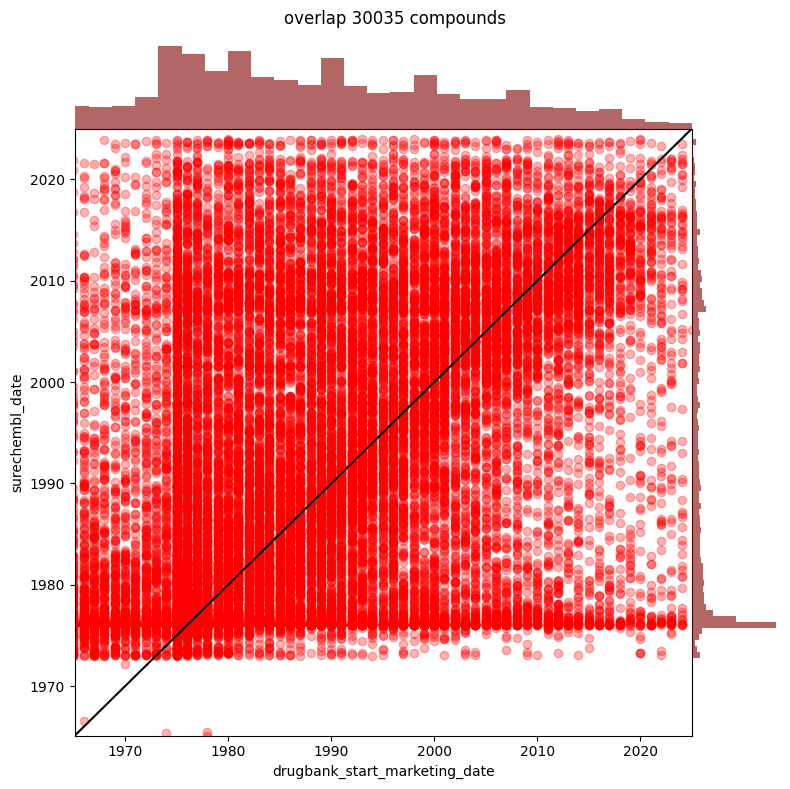

In [47]:
import numpy as np
min_X = np.min(X)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(8, 8, figure=fig, wspace=0.0, hspace=0.0,)

scatter_ax = fig.add_subplot(gs[1:8, 0:7])
scatter_ax.scatter(y, X, alpha=0.3, c="red")

common_min = np.min(X)
common_max = max(np.max(y), np.max(X))

scatter_ax.set_xlim((common_min, common_max))
scatter_ax.set_ylim((common_min, common_max))

x_line = np.linspace(common_min, common_max, 100)
scatter_ax.plot(x_line, x_line, c="black")

scatter_ax.set_xlabel('drugbank_start_marketing_date')
scatter_ax.set_ylabel("surechembl_date")

hist_x_ax = fig.add_subplot(gs[0, 0:7], sharex=scatter_ax)
hist_x_ax.hist(y, bins=100, alpha=0.6, color='maroon')
hist_x_ax.axis('off')

hist_y_ax = fig.add_subplot(gs[1:8, 7], sharey=scatter_ax)
hist_y_ax.hist(X, bins=100, orientation='horizontal', alpha=0.6, color='maroon')
hist_y_ax.axis('off')

fig.suptitle(f"overlap {len(y)} compounds")
plt.tight_layout()

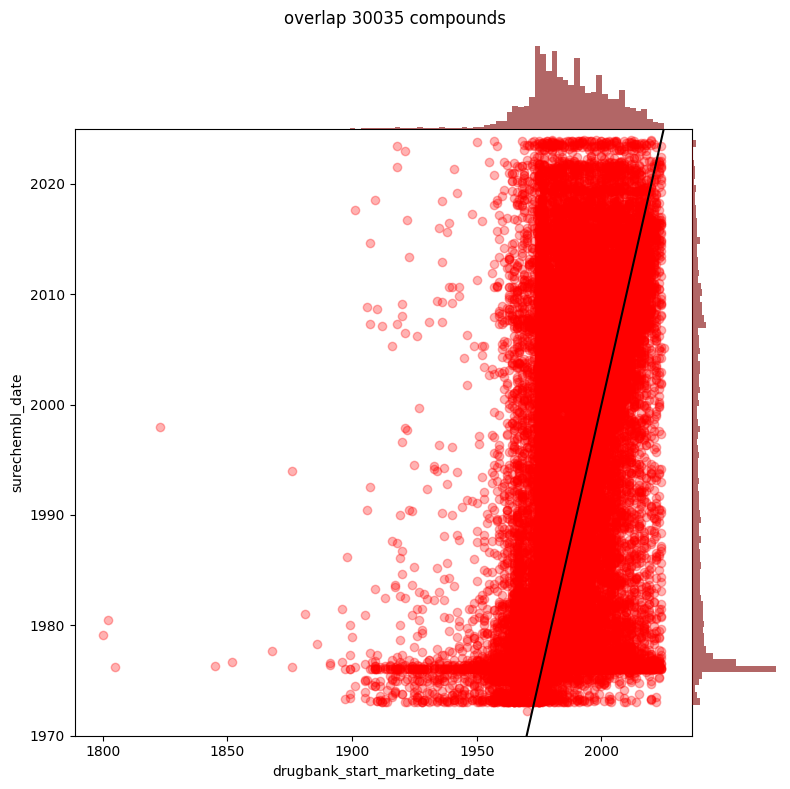

In [48]:
db = y
sc = X

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(8, 8, figure=fig, wspace=0.0, hspace=0.0,)

scatter_ax = fig.add_subplot(gs[1:8, 0:7])
scatter_ax.scatter(db, sc, alpha=0.3, c="red")
x = np.linspace(1880, 2025 , 1000000)
y = x
scatter_ax.plot(x, y, c="black")
scatter_ax.set_ylim((1970,2025))
scatter_ax.set_xlabel('drugbank_start_marketing_date')
scatter_ax.set_ylabel("surechembl_date")

hist_x_ax = fig.add_subplot(gs[0, 0:7], sharex=scatter_ax)
hist_x_ax.hist(db, bins=100, alpha=0.6, color='maroon')
hist_x_ax.axis('off')

hist_y_ax = fig.add_subplot(gs[1:8, 7], sharey=scatter_ax)
hist_y_ax.hist(sc, bins=100, orientation='horizontal', alpha=0.6, color='maroon')
hist_y_ax.axis('off')

fig.suptitle(f"overlap {len(db)} compounds")
plt.tight_layout()

In [49]:
correlation = np.corrcoef(db, sc)[0, 1]
print(f"Correlation coefficient: {correlation:.4f}")

# rank correlation
from scipy.stats import rankdata
x_db_rank = rankdata(db)
x_sc_rank = rankdata(sc)
correlation = np.corrcoef(x_db_rank, x_sc_rank)[0, 1]
print(f"Spearman rank Correlation coefficient: {correlation:.4f}")

# Percentage of compounds whose patents were filed earlier, based on data from 1976 onward when US patent information began to be collected
filtered_indices = [i for i, x in enumerate(db) if x > 1976]
smaller_count = sum(sc[i] < db[i] for i in filtered_indices)
total_count = len(filtered_indices)
smaller_ratio = smaller_count / total_count
print(f"Ratio of data where Shurechembl is faster than drugbank: {smaller_ratio:.4%}")

Correlation coefficient: 0.4239
Spearman rank Correlation coefficient: 0.4566
Ratio of data where Shurechembl is faster than drugbank: 50.3691%
